In [76]:
import numpy as np
from eryn.backends import HDFBackend as eryn_HDF_Backend
import matplotlib.pyplot as plt
import corner
import os
import warnings
import matplotlib.lines as mlines
from matplotlib.font_manager import FontProperties

plt.rcParams['font.size'] = 20

notebook_direc = os.getcwd()
plot_direc = notebook_direc + "/corner_plots"
mcmc_run_direc = "/Users/ollie.burke/Documents/Work/Code/spritz_challenge/code/mbh_pe_runs/data_mcmc_simulations/"
FM_results_direc = "/Users/ollie.burke/Documents/Work/Code/spritz_challenge/code/mbh_pe_runs/fisher_results/"  # For Fisher matrices

# Create plot directory if it doesn't exist
os.makedirs(plot_direc, exist_ok=True)

print("Available MCMC files:")
print(os.listdir(mcmc_run_direc))

Available MCMC files:
['MBH_HMs_case_1_tdi2_SNR_1137_AE_w_noise_no_mask_seed_0.h5', 'MBH_test_with_noise_seed_0.h5', 'MBH_HMs_case_1_SNR_seed_0_.h5']


In [79]:
# MBH parameters - values from mcmc_MBH.py
m1 = 1323277.47932  #/(1 + 1.73941)
m2 =  612485.50602999  #/(1 + 1.73941)
a1 = 0.747377 # spin 1
a2 =  0.8388   # spin 2
inc = np.pi/3 #inclination
dist_Gpc = 36.90249521628649 # luminosity distance

beta = -0.30300442294174235  # ecliptic latitude
lam =   1.2925183861048521 # ecliptic longitude
psi = np.pi/6 # polarization angle

t_ref = 2627744.9218792617
f_ref = 0.0 # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 1.2 # phase at f_ref

M = m1 + m2
q = m2/m1

mbh_params = {
    "M": M,           # Total mass (solar masses)
    "q": q,           # Mass ratio (q >= 1, M1 >= M2)
    "a1": a1,          # Primary spin
    "a2": a2,          # Secondary spin
    "inc": inc,     # Inclination angle
    "dist": dist_Gpc,       # Luminosity distance (Gpc)
    "phi_ref": phi_ref,     # Reference phase
    "lam": lam,     # Ecliptic longitude
    "beta": beta,    # Ecliptic latitude
    "psi": psi,     # Polarization angle
    "t_ref": t_ref
}

# Parameter labels for plotting
param_labels_full = [
    r"$M/M_{\odot}$",      # Total mass
    r"$q$",                 # Mass ratio
    r"$a_1$",               # Primary spin
    r"$a_2$",               # Secondary spin
    r"$\iota$",             # Inclination
    r"$D_L$ [Gpc]",         # Distance
    r"$\phi_{\rm ref}$",    # Reference phase
    r"$\lambda$",           # Ecliptic longitude
    r"$\beta$",             # Ecliptic latitude
    r"$\psi$",              # Polarization angle
    r"$t_{\rm ref}$"        # Reference time
]

true_vals = list(mbh_params.values())
N_params = len(true_vals)

print("MBH Parameters:")
for key, val in mbh_params.items():
    print(f"  {key}: {val}")

MBH Parameters:
  M: 1935762.98534999
  q: 0.4628549307320876
  a1: 0.747377
  a2: 0.8388
  inc: 1.0471975511965976
  dist: 36.90249521628649
  phi_ref: 1.2
  lam: 1.2925183861048521
  beta: -0.30300442294174235
  psi: 0.5235987755982988
  t_ref: 2627744.9218792617


In [80]:
def load_fisher_matrix(file_path):
    """
    Robustly load Fisher matrix results from .npy file.
    Handles various encoding and pickle compatibility issues.
    """
    import pickle
    
    # Method 1: Standard numpy load with .item()
    try:
        FM_results = np.load(file_path, allow_pickle=True).item()
        print("✓ Loaded with np.load().item()")
        return FM_results
    except Exception as e:
        print(f"Method 1 failed: {e}")
    
    # Method 2: Load and access with [()] indexing
    try:
        FM_results = np.load(file_path, allow_pickle=True)[()]
        print("✓ Loaded with np.load()[()]")
        return FM_results
    except Exception as e:
        print(f"Method 2 failed: {e}")
    
    # Method 3: Direct pickle load
    try:
        with open(file_path, 'rb') as f:
            FM_results = pickle.load(f)
        print("✓ Loaded with pickle.load()")
        return FM_results
    except Exception as e:
        print(f"Method 3 failed: {e}")
    
    raise IOError(f"Could not load Fisher matrix from {file_path}. Please regenerate the file by running mcmc_MBH.py")

In [81]:
# Analysis functions for MBH MCMC runs
    
def analyse_samples(file_path, discard=0, plot_log_like=True):
    """
    Load and analyze MCMC samples from HDF5 backend.
    
    Parameters:
    -----------
    file_path : str
        Path to HDF5 file containing MCMC samples
    discard : int
        Number of iterations to discard as burn-in
    plot_log_like : bool
        Whether to plot log-likelihood trace
        
    Returns:
    --------
    samples_after_burnin : list
        Samples for each temperature after burn-in
    reader : HDFBackend
        Backend reader object
    log_like : array
        Log-likelihood values
    N_params : int
        Number of parameters
    """
    reader = eryn_HDF_Backend(file_path, read_only=True)

    N_iterations = reader.get_chain()['model_0'].shape[0]
    N_temps = reader.get_chain()['model_0'].shape[1]
    N_walkers = reader.get_chain()['model_0'].shape[2]
    N_params = reader.get_chain()['model_0'].shape[-1]

    samples_after_burnin = [reader.get_chain(discard=discard)['model_0'][:, i].reshape(-1, N_params) 
                            for i in range(N_temps)]
    
    log_like = reader.get_log_like(discard=discard)

    if plot_log_like:
        plt.figure(figsize=(10, 5))
        plt.plot(log_like[:, 0, :])
        plt.xlabel(r'Iteration')
        plt.ylabel(r'Log likelihood')
        plt.title(f'Log-likelihood trace (N_walkers={N_walkers}, N_temps={N_temps})')
        plt.show()
        
    print(f"Loaded {N_iterations} iterations, {N_walkers} walkers, {N_temps} temps, {N_params} params")
    print(f"After burn-in: {N_iterations - discard} iterations")
    
    return samples_after_burnin, reader, log_like, N_params


def corner_plot(burned_samples, true_params, param_labels, corner_kwargs, title=r'Corner plot', plot_name=None):
    """
    Create corner plot with true parameter values overlaid.
    
    Parameters:
    -----------
    burned_samples : list
        List of samples after burn-in (from analyse_samples)
    true_params : array
        True parameter values
    param_labels : list
        Parameter labels for axes
    corner_kwargs : dict
        Additional kwargs for corner.corner()
    title : str
        Plot title
    plot_name : str, optional
        Path to save plot
        
    Returns:
    --------
    figure : matplotlib.figure.Figure
        Corner plot figure
    """
    N_params = len(param_labels)
    true_params = true_params[0:N_params]
    trunc_samples = burned_samples[0][:, :N_params]
    
    print(f"Plotting {trunc_samples.shape[0]} samples for {N_params} parameters")
    
    figure = corner.corner(trunc_samples, bins=30, color='blue', **corner_kwargs)
    
    axes = np.array(figure.axes).reshape((N_params, N_params))

    # Add true values as vertical/horizontal lines
    for i in range(N_params):
        ax = axes[i, i]
        ax.axvline(true_params[i], color="k", lw=2)

    for yi in range(N_params):
        for xi in range(yi):
            ax = axes[yi, xi]
            ax.axhline(true_params[yi], color="k", lw=1)
            ax.axvline(true_params[xi], color="k", lw=1)
            ax.plot(true_params[xi], true_params[yi], "sk", markersize=8)

    for ax in figure.get_axes():
        ax.tick_params(axis='both', labelsize=18)

    # Legend
    blue_line = mlines.Line2D([], [], color='blue', label=r'Posterior Distributions')
    black_line = mlines.Line2D([], [], color='black', label='True Value')
    
    if plot_name:
        plt.savefig(plot_name, bbox_inches="tight", dpi=150)
        print(f"Saved plot to {plot_name}")
        
    return figure


def remove_bad_walkers(reader_from_sampler, log_like_threshold=-170, burn=400, plot_log_like=True):
    """
    Filter out walkers that fall below log-likelihood threshold.
    
    Parameters:
    -----------
    reader_from_sampler : HDFBackend
        Backend reader object
    log_like_threshold : float
        Threshold below which walkers are considered "bad"
    burn : int
        Burn-in to discard before filtering
    plot_log_like : bool
        Whether to plot cleaned log-likelihood
        
    Returns:
    --------
    filtered_log_like : array
        Cleaned log-likelihood values
    recast_samples : list
        Cleaned samples for each temperature
    """
    N_temps = reader_from_sampler.get_chain()['model_0'].shape[1]
    N_params = reader_from_sampler.get_chain()['model_0'].shape[-1]
    samples = reader_from_sampler.get_chain(discard=burn)['model_0']
    log_like = reader_from_sampler.get_log_like(discard=burn)
    
    # Identify walkers that ever go below the threshold
    bad_walkers = np.any(log_like < log_like_threshold, axis=0)
    good_walkers_mask = ~bad_walkers.squeeze()
    
    # Apply the mask
    filtered_log_like = log_like[:, :, good_walkers_mask]
    filtered_samples = samples[:, :, good_walkers_mask, :, :]
    
    recast_samples = [filtered_samples[:, i].reshape(-1, N_params) for i in range(N_temps)]
    
    print(f"Removed {np.sum(~good_walkers_mask)} bad walkers, kept {np.sum(good_walkers_mask)}")

    if plot_log_like:
        plt.figure(figsize=(10, 5))
        plt.plot(filtered_log_like[:, 0, :])
        plt.xlabel(r'Iteration')
        plt.ylabel(r'Log likelihood (cleaned)')
        plt.title('Log-likelihood after removing bad walkers')
        plt.show()
    
    return filtered_log_like, recast_samples


def save_samples_h5(samples, no_samples=30000, true_vals=None, 
                    file_name="samples.h5", param_labels=None,
                    file_path=None):
    """
    Save MCMC samples to HDF5 file.
    
    Parameters:
    -----------
    samples : list
        Samples from analyse_samples
    no_samples : int
        Number of most recent samples to save
    true_vals : array
        True parameter values
    file_name : str
        Output filename
    param_labels : list
        Parameter labels
    file_path : str
        Directory path
    """
    import h5py
    
    samples_array = samples[0]
    truncated_samples = samples_array[-no_samples:, :]
    
    if param_labels is None:
        param_labels = [f"param_{i}" for i in range(truncated_samples.shape[1])]
    
    samples_dict = {
        label: truncated_samples[:, i] for i, label in enumerate(param_labels)
    }
    
    full_path = os.path.join(file_path, file_name) if file_path else file_name
    
    with h5py.File(full_path, "w") as f:
        for key, values in samples_dict.items():
            f.create_dataset(f"samples/{key}", data=values)
        
        if true_vals is not None:
            f.create_dataset("true_values", data=true_vals)
        
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset("param_labels", data=np.array(param_labels, dtype=dt))
    
    print(f"Saved {no_samples} samples to {full_path}")


def load_samples_h5(file_path):
    """Load saved samples from HDF5 file."""
    import h5py
    
    with h5py.File(file_path, "r") as f:
        param_labels = [label.decode('utf-8') if isinstance(label, bytes) else label
                        for label in f["param_labels"][()]]
        
        true_vals = f["true_values"][()] if "true_values" in f else None
        
        samples_dict = {}
        for label in param_labels:
            samples_dict[label] = f[f"samples/{label}"][()]
    
    return samples_dict, param_labels, true_vals

## Load and Analyze MCMC Results

# Load MCMC samples from the HDF5 backend and plot log-likelihood traces.

Analyzing MBH test run...


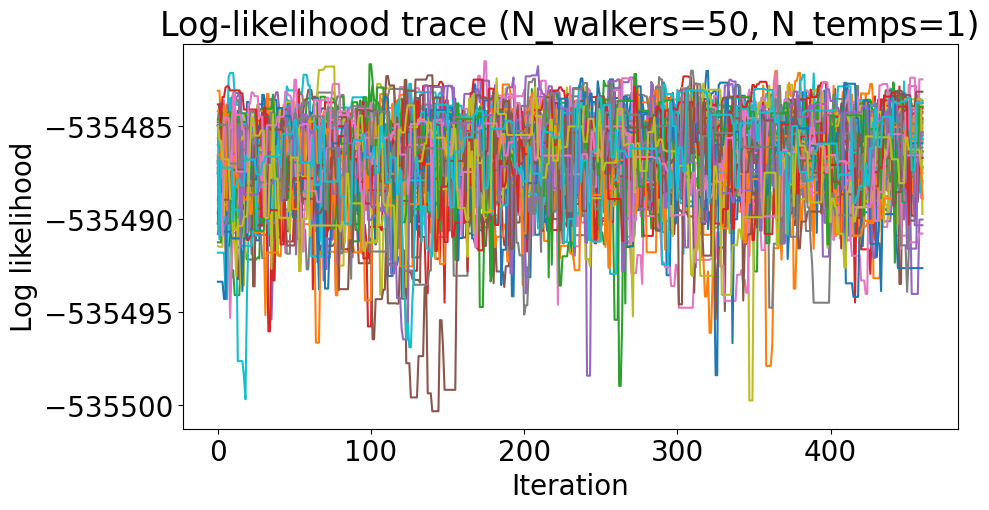

Loaded 611 iterations, 50 walkers, 1 temps, 11 params
After burn-in: 461 iterations


In [92]:
# File paths for MBH MCMC runs
file_path_test = mcmc_run_direc + 'MBH_HMs_case_1_tdi2_SNR_1137_AE_w_noise_no_mask_seed_0.h5'

# Add more file paths as you generate more runs:
# file_path_seed_0 = mcmc_run_direc + 'MBH_seed_0.h5'
# file_path_seed_1 = mcmc_run_direc + 'MBH_seed_1.h5'
# etc.

# Load and analyze samples
print("Analyzing MBH test run...")
burned_samples_test, reader_test, log_like_test, N_params = analyse_samples(
    file_path_test, 
    discard=150,  # Adjust burn-in as needed
    plot_log_like=True
)

# If you have multiple runs, you can load them like this:
# burned_samples_seed_0, reader_seed_0, log_like_0, _ = analyse_samples(file_path_seed_0, discard=1000)
# burned_samples_seed_1, reader_seed_1, log_like_1, _ = analyse_samples(file_path_seed_1, discard=1000)

In [93]:
## Clean Samples (Optional)

# Remove walkers with poor log-likelihood values if needed.

In [94]:
# Optional: Remove bad walkers if needed
# Uncomment and adjust threshold as needed
# filtered_log_like_test, cleaned_samples_test = remove_bad_walkers(
#     reader_test, 
#     log_like_threshold=-170,  # Adjust based on your likelihood values
#     burn=400, 
#     plot_log_like=True
# )

# If you cleaned the samples, use cleaned_samples_test instead of burned_samples_test below

## Generate Corner Plots

Create corner plots showing posterior distributions with true parameter values.

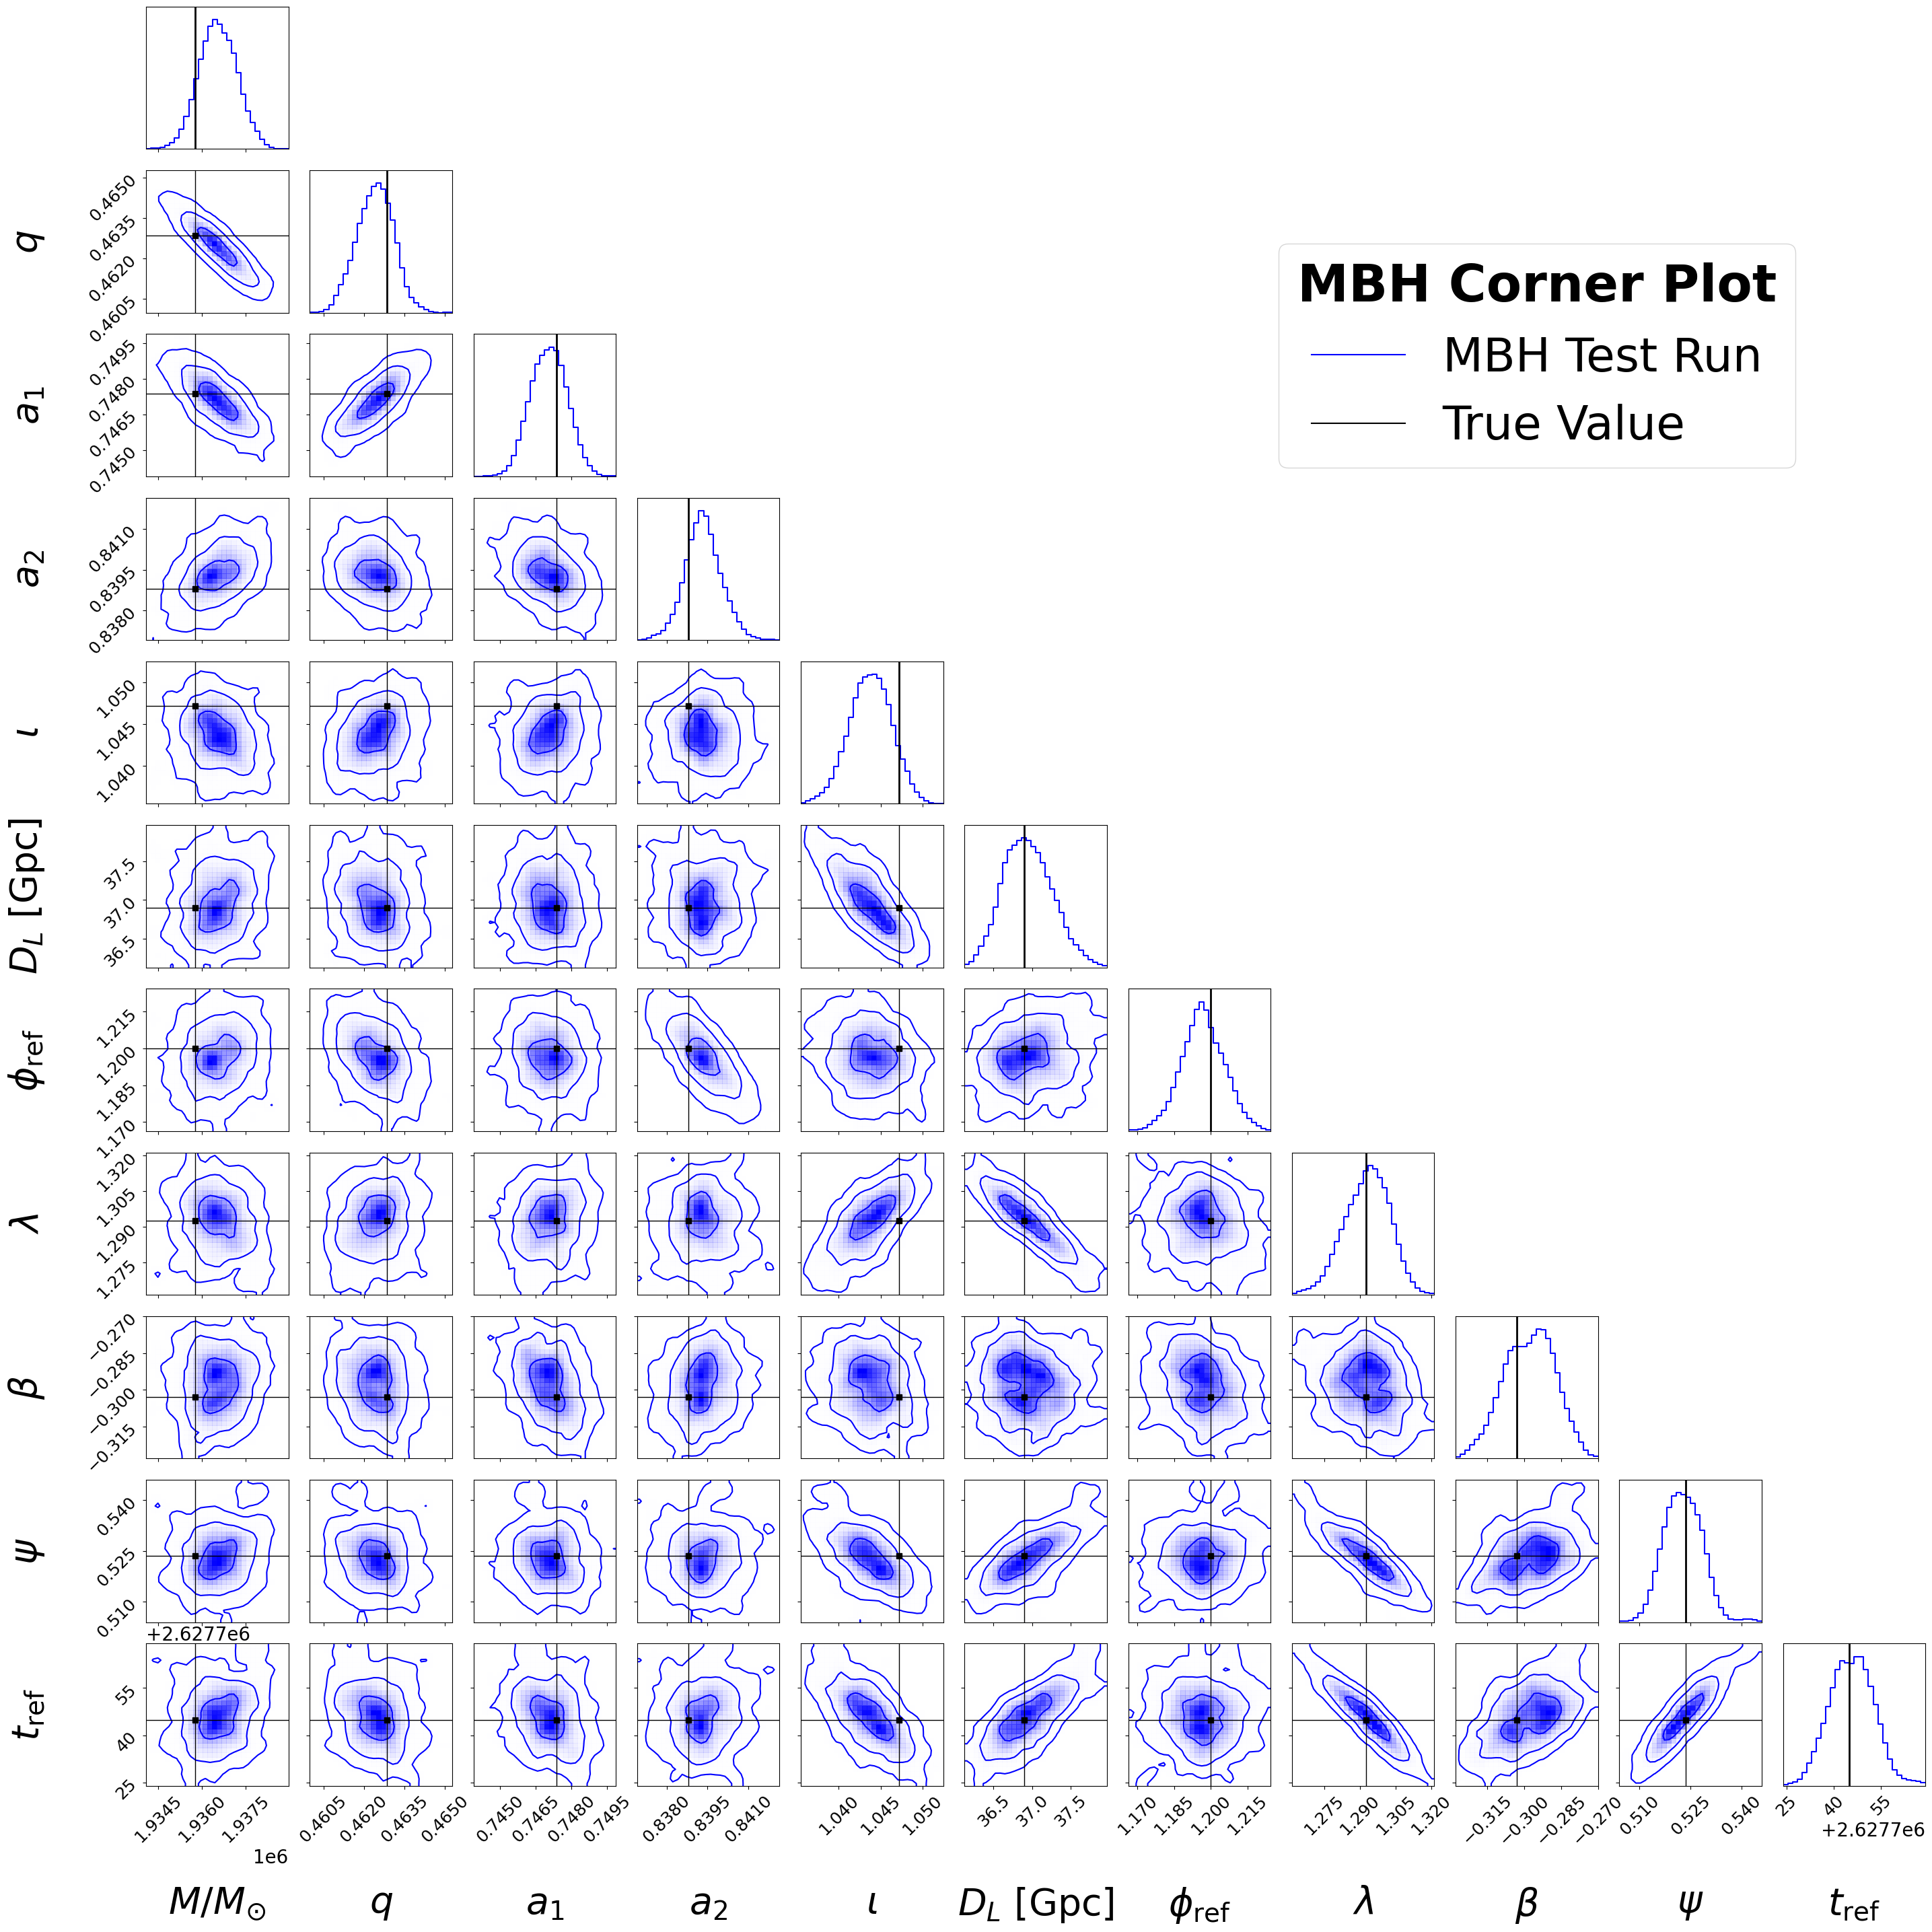

In [95]:
# Set up corner plot kwargs
corner_kwargs = dict(
    plot_datapoints=False,
    smooth1d=True,
    labels=param_labels_full, 
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9/2.)), 
    label_kwargs=dict(fontsize=40), 
    max_n_ticks=4,
    show_titles=False, 
    smooth=True, 
    labelpad=0.4
)

# Create corner plot for test run
samples_corner_test = burned_samples_test[0]

figure = corner.corner(samples_corner_test, bins=30, color='blue', **corner_kwargs)

# Add true values
axes = np.array(figure.axes).reshape((N_params, N_params))

for i in range(N_params):
    ax = axes[i, i]
    ax.axvline(true_vals[i], color="k", lw=2)

for yi in range(N_params):
    for xi in range(yi):
        ax = axes[yi, xi]
        ax.axhline(true_vals[yi], color="k", lw=1)
        ax.axvline(true_vals[xi], color="k", lw=1)
        ax.plot(true_vals[xi], true_vals[yi], "sk", markersize=6)

for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=18)

# Legend
blue_line = mlines.Line2D([], [], color='blue', label=r'MBH Test Run')
black_line = mlines.Line2D([], [], color='black', label='True Value')

plt.legend(
    handles=[blue_line, black_line], 
    fontsize=50, 
    frameon=True, 
    bbox_to_anchor=(0.25, N_params), 
    loc="upper right", 
    title="MBH Corner Plot", 
    title_fontproperties=FontProperties(size=55, weight='bold')
)
plt.subplots_adjust(left=-0.1, bottom=-0.1, wspace=0.15, hspace=0.15)

# Save plot
plot_name = os.path.join(plot_direc, "corner_plot_MBH_test.png")
# plt.savefig(plot_name, bbox_inches="tight", dpi=150)
# print(f"Saved corner plot to {plot_name}")

plt.show()

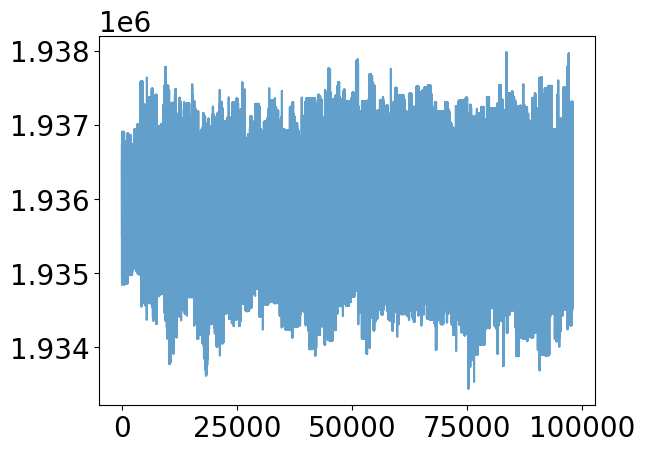

(array([5.000e+00, 1.500e+01, 5.500e+01, 1.230e+02, 2.230e+02, 4.500e+02,
        8.730e+02, 1.486e+03, 2.540e+03, 3.302e+03, 4.204e+03, 5.608e+03,
        7.675e+03, 8.521e+03, 8.673e+03, 9.383e+03, 8.996e+03, 8.667e+03,
        7.907e+03, 5.896e+03, 4.517e+03, 3.090e+03, 2.299e+03, 1.477e+03,
        8.080e+02, 6.980e+02, 3.230e+02, 1.020e+02, 1.800e+01, 1.600e+01]),
 array([1933445.18787636, 1933596.30151514, 1933747.41515393,
        1933898.52879271, 1934049.64243149, 1934200.75607028,
        1934351.86970906, 1934502.98334784, 1934654.09698662,
        1934805.21062541, 1934956.32426419, 1935107.43790297,
        1935258.55154176, 1935409.66518054, 1935560.77881932,
        1935711.89245811, 1935863.00609689, 1936014.11973567,
        1936165.23337445, 1936316.34701324, 1936467.46065202,
        1936618.5742908 , 1936769.68792959, 1936920.80156837,
        1937071.91520715, 1937223.02884594, 1937374.14248472,
        1937525.2561235 , 1937676.36976228, 1937827.48340107,
        

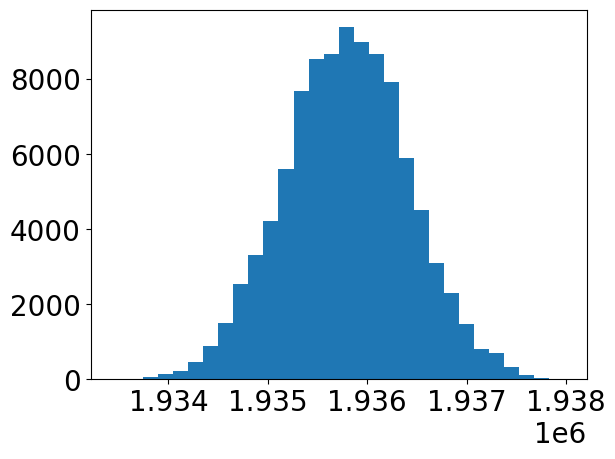

In [50]:
plt.plot(samples_corner_test[:, 0], alpha=0.7)
plt.show()

plt.hist(samples_corner_test[:, 0], bins=30)

## Compare Multiple Runs (Optional)

If you have multiple MCMC runs (e.g., different seeds), you can compare them here.

In [32]:
# Example: Compare two different runs
# Uncomment when you have multiple runs

# samples_corner_seed_0 = burned_samples_seed_0[0]
# samples_corner_seed_1 = burned_samples_seed_1[0]

# figure = corner.corner(samples_corner_seed_0, bins=30, color='blue', **corner_kwargs)

# # Overlay second run with weights to normalize histogram heights
# weights = (len(samples_corner_seed_0) / len(samples_corner_seed_1)) * np.ones(len(samples_corner_seed_1))
# corner.corner(samples_corner_seed_1, fig=figure, bins=30, weights=weights, color='red', **corner_kwargs)

# # Add true values and legend
# axes = np.array(figure.axes).reshape((N_params, N_params))

# for i in range(N_params):
#     ax = axes[i, i]
#     ax.axvline(true_vals[i], color="k", lw=2)

# for yi in range(N_params):
#     for xi in range(yi):
#         ax = axes[yi, xi]
#         ax.axhline(true_vals[yi], color="k", lw=1)
#         ax.axvline(true_vals[xi], color="k", lw=1)
#         ax.plot(true_vals[xi], true_vals[yi], "sk", markersize=6)

# for ax in figure.get_axes():
#     ax.tick_params(axis='both', labelsize=18)

# blue_line = mlines.Line2D([], [], color='blue', label=r'Seed 0')
# red_line = mlines.Line2D([], [], color='red', label=r'Seed 1')
# black_line = mlines.Line2D([], [], color='black', label='True Value')

# plt.legend(
#     handles=[blue_line, red_line, black_line], 
#     fontsize=50, 
#     frameon=True, 
#     bbox_to_anchor=(0.25, N_params), 
#     loc="upper right",
#     title="Comparison", 
#     title_fontproperties=FontProperties(size=55, weight='bold')
# )

# plt.savefig(os.path.join(plot_direc, "corner_comparison_MBH.png"), bbox_inches="tight", dpi=150)
# plt.show()

## Fisher Matrix Comparison (Optional)

# Load Fisher matrix samples and compare with MCMC posteriors.

In [47]:
load_fisher_matrix(FM_results_direc + "fisher_results.npy")  # Test loading function

Method 1 failed: _reconstruct: First argument must be a sub-type of ndarray
Method 2 failed: _reconstruct: First argument must be a sub-type of ndarray
Method 3 failed: STACK_GLOBAL requires str


OSError: Could not load Fisher matrix from /Users/ollie.burke/Documents/Work/Code/spritz_challenge/code/mbh_pe_runs/fisher_results/fisher_results.npy. Please regenerate the file by running mcmc_MBH.py

In [36]:
os.listdir(FM_results_direc)

['fisher_results.npy']

In [38]:
# Try loading with different methods to diagnose the issue
import pickle

# Method 1: Try loading as a pickle directly
try:
    with open(FM_results_direc + "fisher_results.npy", 'rb') as f:
        FM_results = pickle.load(f)
    print("Loaded successfully as pickle!")
    print(f"Type: {type(FM_results)}")
    print(f"Keys: {FM_results.keys() if isinstance(FM_results, dict) else 'Not a dict'}")
except Exception as e:
    print(f"Pickle load failed: {e}")

# Method 2: Try loading with encoding parameter
try:
    FM_results = np.load(FM_results_direc + "fisher_results.npy", 
                         allow_pickle=True, 
                         encoding='latin1')
    print("Loaded with latin1 encoding!")
except Exception as e:
    print(f"Latin1 load failed: {e}")

# Method 3: Try loading with different encoding
try:
    FM_results = np.load(FM_results_direc + "fisher_results.npy", 
                         allow_pickle=True, 
                         encoding='bytes')
    print("Loaded with bytes encoding!")
except Exception as e:
    print(f"Bytes load failed: {e}")

Pickle load failed: STACK_GLOBAL requires str
Latin1 load failed: _reconstruct: First argument must be a sub-type of ndarray
Bytes load failed: _reconstruct: First argument must be a sub-type of ndarray


In [39]:
FM_results = np.load(FM_results_direc + "fisher_results.npy", allow_pickle=True)

TypeError: _reconstruct: First argument must be a sub-type of ndarray

In [34]:
# Load Fisher Matrix results (when available)
# You'll need to save your Fisher matrices as .npy files first

# Example structure (uncomment when you have Fisher matrices):
FM_results = np.load(FM_results_direc + "fisher_results.npy", allow_pickle=True).item()
Cov_Matrix = FM_results['Cov_Matrix']
# # Generate samples from Fisher matrix
N_samples = len(burned_samples_test[0])
FM_samples = np.random.multivariate_normal(true_vals, Cov_Matrix, N_samples)

# # Compare MCMC vs Fisher Matrix
figure = corner.corner(burned_samples_test[0], bins=30, color='blue', **corner_kwargs)
corner.corner(FM_samples, fig=figure, bins=30, color='red', **corner_kwargs)

# # Add true values
axes = np.array(figure.axes).reshape((N_params, N_params))

for i in range(N_params):
    ax = axes[i, i]
    ax.axvline(true_vals[i], color="k", lw=2)

for yi in range(N_params):
    for xi in range(yi):
        ax = axes[yi, xi]
        ax.axhline(true_vals[yi], color="k", lw=1)
        ax.axvline(true_vals[xi], color="k", lw=1)
        ax.plot(true_vals[xi], true_vals[yi], "sk", markersize=6)

for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=18)

blue_line = mlines.Line2D([], [], color='blue', label=r'MCMC')
red_line = mlines.Line2D([], [], color='red', label=r'Fisher Matrix')
# black_line = mlines.Line2D([], [], color='black', label='True Value')

plt.legend(
    handles=[blue_line, red_line, black_line], 
    fontsize=50, 
    frameon=True, 
    bbox_to_anchor=(0.25, N_params), 
    loc="upper right", 
    title="MCMC vs Fisher", 
    title_fontproperties=FontProperties(size=55, weight='bold')
)

# plt.savefig(os.path.join(plot_direc, "corner_MCMC_vs_Fisher_MBH.png"), bbox_inches="tight", dpi=150)
plt.show()

print("Fisher Matrix comparison code ready (uncomment when you have Fisher matrices saved)")

TypeError: _reconstruct: First argument must be a sub-type of ndarray

## Save Processed Samples

Save the processed samples for later use or sharing.

In [ ]:
# Save processed samples to HDF5
save_samples_h5(
    burned_samples_test,
    no_samples=30000,  # Save last 30k samples
    true_vals=true_vals,
    file_name="MBH_test_processed_samples.h5",
    param_labels=param_labels_full,
    file_path=mcmc_run_direc
)

# To load later:
# samples_dict, labels, true_values = load_samples_h5(mcmc_run_direc + "MBH_test_processed_samples.h5")

In [61]:
import h5py

BH_directory = "/Users/ollie.burke/Documents/Work/Code/spritz_challenge/code/Light_Spritz"

data = "LDC2_Spritz_only_GW.h5"

# Full path to the data file
data_path = os.path.join(BH_directory, data)

# Read the HDF5 file
with h5py.File(data_path, 'r') as f:
    print("Keys in HDF5 file:")
    print(list(f.keys()))

    MBH_strain = f['time_series'][:]
    
    # Print structure of the file
    def print_structure(name, obj):
        print(name)
    f.visititems(print_structure)

Keys in HDF5 file:
['time_series']
time_series


(11525000.0, 11528000.0)

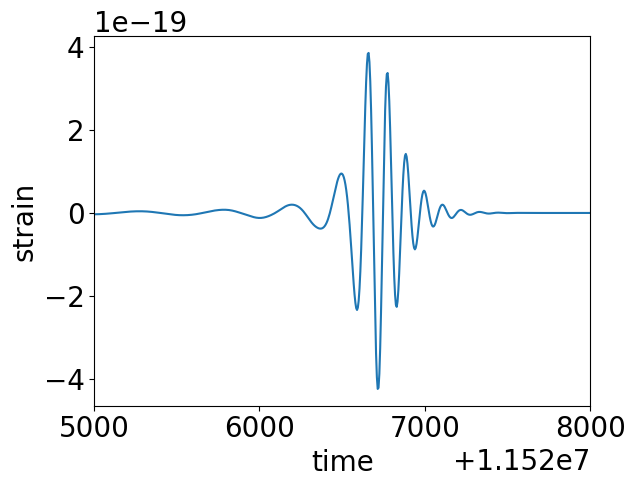

In [75]:
import matplotlib.pyplot as plt 
time = MBH_strain[:,0]
MBH_A = MBH_strain[:,1]

plt.plot(time,MBH_A)
plt.xlabel(r'time')
plt.ylabel(r'strain')
plt.xlim([1.1525e7,1.1528e7])

In [54]:
MBH_strain

<Closed HDF5 dataset>